In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

##DISPLAY SETTINGS

# Show all columns
pd.set_option('display.max_columns', None)

# Auto-adjust display width
pd.set_option('display.width', None)

# Prevent column wrapping
pd.set_option('display.expand_frame_repr', False)

# Show up to 100 rows
pd.set_option('display.max_rows', 100)

# Show full text in cells
pd.set_option('display.max_colwidth', None)

# Show floats with 2 decimal places
pd.set_option('display.precision', 2)

# Format floats with commas
pd.options.display.float_format = '{:,.2f}'.format

## Kaggle Workflow

In [19]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Save target
y = train_df["Purchase"]

# Remove target before combining
train_df = train_df.drop("Purchase", axis=1)

# Combine
df = pd.concat([train_df, test_df], ignore_index=True)

# EDA + preprocessing
...

Ellipsis

## Loading the Data

In [20]:
train_df = pd.read_csv("train.csv")
train_df.head()


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.00,14.00,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.00,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [21]:
## import test data
test_df= pd.read_csv("test.csv")

In [22]:
df=pd.concat([train_df,test_df], ignore_index=True, axis=0)

In [23]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [24]:
df.shape

(783667, 12)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [26]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,"783,667.00","783,667.00","783,667.00","783,667.00","537,685.00","237,858.00","550,068.00"
mean,"1,003,029.00",8.08,0.41,5.37,9.84,12.67,"9,263.97"
std,"1,727.27",6.52,0.49,3.88,5.09,4.13,"5,023.07"
min,"1,000,001.00",0.00,0.00,1.00,2.00,3.00,12.00
25%,"1,001,519.00",2.00,0.00,1.00,5.00,9.00,"5,823.00"
50%,"1,003,075.00",7.00,0.00,5.00,9.00,14.00,"8,047.00"
75%,"1,004,478.00",14.00,1.00,8.00,15.00,16.00,"12,054.00"
max,"1,006,040.00",20.00,1.00,20.00,18.00,18.00,"23,961.00"


## Data Cleaning and Transformation

In [27]:
df = df.drop(['User_ID', 'Product_ID'], axis=1)

In [28]:
NA=df.isnull().sum().sort_values(ascending=False)
print(f"Total number of missing values in the dataset: \n{NA}")

Total number of missing values in the dataset: 
Product_Category_3            545809
Product_Category_2            245982
Purchase                      233599
Gender                             0
Age                                0
Occupation                         0
Marital_Status                     0
Stay_In_Current_City_Years         0
City_Category                      0
Product_Category_1                 0
dtype: int64


In [29]:
## percentage of missing values
NA_percentage= (df.isnull().mean()*100).sort_values(ascending=False)
print(f"Percentage of missing values in the dataset :\n{NA_percentage}")

Percentage of missing values in the dataset :
Product_Category_3           69.65
Product_Category_2           31.39
Purchase                     29.81
Gender                        0.00
Age                           0.00
Occupation                    0.00
Marital_Status                0.00
Stay_In_Current_City_Years    0.00
City_Category                 0.00
Product_Category_1            0.00
dtype: float64


Observation
- **Product_Category_3** has **69.67%** missing values, making it the column with the highest proportion of missing data.
- **Product_Category_2** has **31.57%** missing values.
- All other columns have **no missing values (0%)**.

<Axes: >

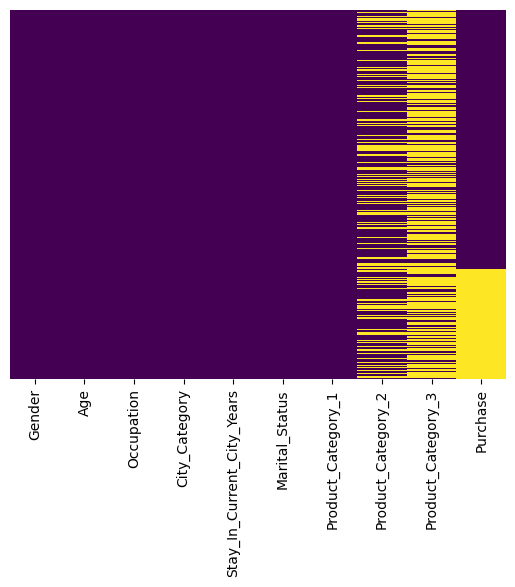

In [30]:
## understanding null values via heatmap 
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap='viridis')

In [31]:
## Handling Missing Values
df['Product_Category_3'] = df['Product_Category_3'].fillna(df['Product_Category_3'].mode()[0])

In [32]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(df['Product_Category_2'].mode()[0])


In [33]:
## Separating numerical and categorical values
numerical_values = df.select_dtypes(include=[np.number]).columns.to_list()
categorical_values = df.select_dtypes(include=[object]).columns.to_list()

print(numerical_values)
print(categorical_values)

['Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']
['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']


# Automated EDA

### Step 1 — Automated EDA

This answers:

"What is in my dataset?"

It tells you things like:

Dataset shape
Missing values
Duplicates
Data types
Histograms
Correlations
Skewness
Outliers
Cardinality
Constant columns
Sample rows

This is incredibly useful because it saves 30–60 minutes of repetitive work.

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df,title="Black Friday Dataset Report",explorative=True)

profile.to_file("Black_Friday_Report.html")
profile.to_notebook_iframe()

## Exploratory Data Analysis (EDA)

### Dataset Overview

- The dataset contains **783,667 observations** and **10 features**, consisting of **5 categorical** and **5 numerical** variables. 
- It captures customer demographic information and purchasing behavior collected during a Black Friday sales event.



## Data Quality Summary

Initial profiling revealed several characteristics requiring further investigation:

- The dataset contains **40,943 duplicate rows (5.2%)**.
- Approximately **3% of all cells contain missing values**.
- `Product_Category_2` and `Product_Category_3` exhibit a strong correlation.
- `Occupation` contains a noticeable proportion of zero values.

These observations guide the subsequent preprocessing and feature engineering steps.

#### Missing Value Analysis

- Missing values are primarily concentrated in the product category features. 
- Such missing values are expected because not every purchased product belongs to multiple product categories.

The handling strategy for these missing values is discussed in the preprocessing section.

#### Correlation Analysis

- The report indicates a strong correlation between `Product_Category_2` and `Product_Category_3`. 
- This relationship is expected because both variables describe related product classifications.

A detailed correlation analysis will be performed later to evaluate whether this relationship affects feature selection or model performance.

## Manual EDA

#### ~ Doing bivariate analnalysis on Target variable

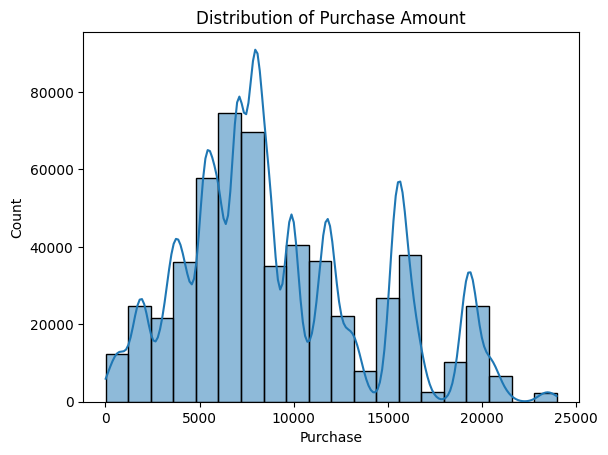

In [34]:
sns.histplot(df['Purchase'], kde=True,bins=20)
plt.title("Distribution of Purchase Amount")
plt.show()

- The distribution is **not normally distributed** and exhibits a **positively skewed (right-skewed)** pattern.
- The majority of purchase amounts lie between **₹5,000 and ₹10,000**, indicating this is the most common spending range.
- The frequency gradually decreases for purchase amounts above **₹15,000**, indicating fewer high-value transactions.
- Very high purchase amounts (**above ₹22,000**) occur rarely and may represent potential outliers or premium purchases.

Gender
F   7,914.00
M   8,098.00
Name: Purchase, dtype: float64

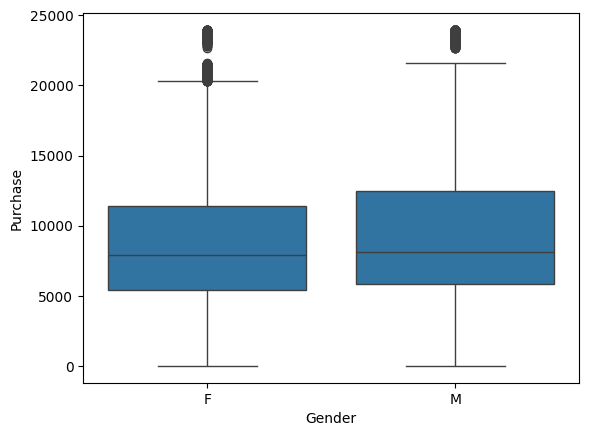

In [35]:
sns.boxplot(x='Gender', y='Purchase', data=df)
df.groupby('Gender')['Purchase'].median()

- Male customers tend to spend **slightly more on average**, but the difference is not substantial.
- The larger spread in male purchases indicates a more diverse spending pattern.
- both groups contain high-value outliers

Age
0-17    7,986.00
18-25   8,027.00
26-35   8,030.00
36-45   8,061.00
46-50   8,036.00
51-55   8,130.00
55+     8,105.50
Name: Purchase, dtype: float64

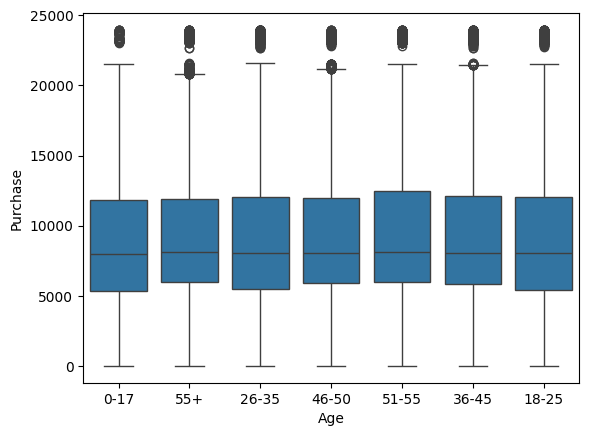

In [36]:
sns.boxplot(x='Age', y='Purchase', data=df)
df.groupby('Age')['Purchase'].median()

- The median purchase amount is relatively similar across all age groups, with only slight variations.
- Customers in the **51–55** age group have the **highest median purchase amount

City_Category
A   7,931.00
B   8,005.00
C   8,585.00
Name: Purchase, dtype: float64

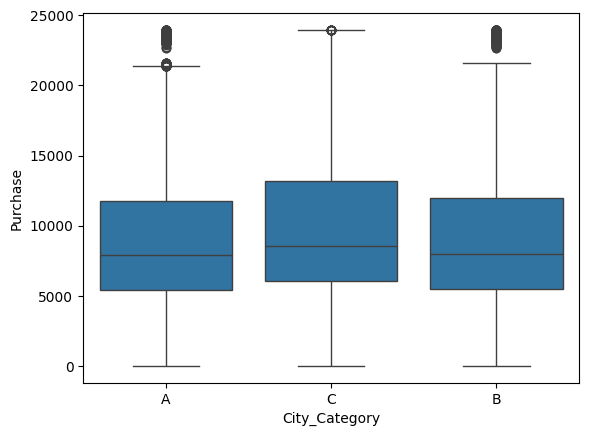

In [37]:
sns.boxplot(x='City_Category', y='Purchase', data=df)
df.groupby('City_Category')['Purchase'].median()

- Customers in **City Category C** tend to spend **slightly more** than those in Categories A and B.
- The larger spread in Category C indicates a more diverse customer base with a wider range of purchase behaviors.

### Multivariate Analysis

<Axes: xlabel='Age', ylabel='Purchase'>

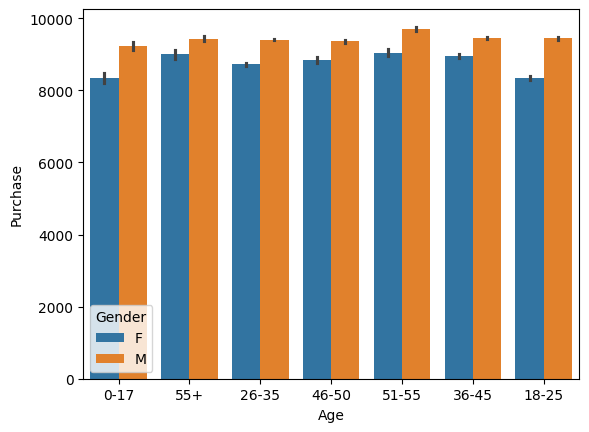

In [38]:
sns.barplot(x='Age',y='Purchase',hue='Gender',data=df)

#### Key Observations

- Across every age group, **Male (M)** customers have a higher average purchase than **Female (F)** customers.
- The difference between males and females is consistent, roughly **400–1100 units** depending on the age group.
- The **51–55** age group has the highest average purchase for both genders.
- The **18–25** age group has the lowest average purchase among females.
- Male purchase values remain relatively stable across age groups (around **9200–9700**), while female purchases show slightly more variation.

- **Gender appears to have a stronger influence on purchase amount than age**, as males consistently spend more than females.
- **Middle-aged customers (51–55)** contribute the highest average purchase and may represent a valuable customer segment.